# Laboratorio 7: NLP end-to-end y embeddings
**Javier Valladares (23045) e Ian Cumes (23236)**  
CC3092 · 05/10/2026

Este notebook documenta el pipeline completo y muestra los resultados de entrenamientos reales guardados en `results/`. Los módulos `src/` forman parte de la entrega y contienen el código comentado. La implementación SGNS propia utiliza PyTorch; gensim Word2Vec se usa únicamente como referencia separada.

**Ejecución:** instalar `requirements.txt`, abrir desde la raíz del repositorio y ejecutar todas las celdas. Por defecto se revisa la ejecución guardada. Para reconstruir corpus/modelos, activar `REENTRENAR=True` y ejecutar el bloque de reproducción. Los resultados de test ya existentes se reutilizan para mantener su evaluación única; para un experimento nuevo debe usarse otro directorio de resultados. No se reemplazan resultados faltantes por números inventados.

In [1]:
from pathlib import Path
import json, sys, subprocess, platform, inspect, re, unicodedata
import numpy as np
import os
os.environ.setdefault('TORCH_DEVICE_BACKEND_AUTOLOAD', '0')
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from numba import njit
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
assert (ROOT / 'src').is_dir(), 'Abrir desde la raíz del repositorio.'
# Descomprimir los vectores distribuidos en GitHub, si hace falta.
if not (ROOT / 'models/mejor_sgns.txt').exists() and (ROOT / 'models/mejor_sgns.txt.gz').exists():
    import gzip, shutil
    with gzip.open(ROOT / 'models/mejor_sgns.txt.gz', 'rb') as source, (ROOT / 'models/mejor_sgns.txt').open('wb') as target:
        shutil.copyfileobj(source, target)
sys.path.insert(0, str(ROOT))
REENTRENAR = False
def resultado(name):
    return json.loads((ROOT / 'results' / name).read_text())
def figura(name):
    display(Image(filename=str(ROOT / 'figures' / name)))
print('Python', platform.python_version(), '| PyTorch', torch.__version__)
print('MPS disponible:', torch.backends.mps.is_available(), '| SGNS ejecutado en CPU, 4 hilos')


Python 3.12.14 | PyTorch 2.14.1
MPS disponible: True | SGNS ejecutado en CPU, 4 hilos


## 1. Datos y protocolo
Se descargan **Salesforce/wikitext, wikitext-103-raw-v1**, **fancyzhx/ag_news** y **glove-wiki-gigaword-100**. Las descargas están en `data/` (omitido de Git). El subconjunto es un prefijo determinista de 22 millones de tokens normalizados de train; después de min_count=20 quedan 21,336,925. Las ventanas respetan líneas. El prefijo puede introducir sesgo temático; las fracciones menores son ablaciones.

Se mantiene el mismo corpus filtrado y vocabulario para el SGNS principal y la referencia gensim. Para las ablaciones de tamaño se conserva el vocabulario del subconjunto completo, haciendo explícito que algunas filas quedan sin entrenar. Los benchmarks comparten candidatos.

In [2]:
# Reproducción del pipeline completo. No se ejecuta entrenamiento al revisar resultados.
if REENTRENAR:
    subprocess.run([sys.executable, 'scripts/run_all.py'], check=True)
prep = resultado('preprocessing.json')
display(pd.DataFrame(prep['splits']).T)
print('Subconjunto normalizado:', prep['subset_tokens'])
print('Tokens conocidos:', prep['known_tokens'], '| vocabulario:', prep['vocab_size'])
assert prep['known_tokens'] >= 20_000_000


,lines,nonempty_lines,articles,tokens
test,4358,2891,62,207485
train,1801350,1165029,29443,86951330
validation,3760,2461,60,184480


Subconjunto normalizado: 22000000
Tokens conocidos: 21336925 | vocabulario: 38569


## 2. Exploración, normalización y tokenización
NFKC/minúsculas y regex ASCII para inglés (los acentos pueden fragmentar nombres); separación de puntuación, apóstrofos y guiones; números literales; eliminación de etiquetas especiales y marcadores WikiText. No stopwords, stemming o lematización. Minúsculas/formas léxicas son compatibles con GloVe uncased, pero sus reglas exactas pueden diferir: se reporta OOV. El conteo de artículos usa encabezados de nivel uno (`= título =`), no cada subsección.

El regex conserva decimales escritos con punto/coma y fragmenta contracciones. Esta es una simplificación explícita: puede producir `t` y `s` de las contracciones. Treebank de NLTK separa sufijos como `n't`, mantiene cierta puntuación y trata abreviaturas de otra manera.

In [3]:
TOKEN_RE = re.compile(r"[a-z]+|[0-9]+(?:[.,][0-9]+)*")
def normalize(text):
    text = unicodedata.normalize('NFKC', text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    return re.sub(r'@[-.,]@', ' ', text)
def tokenize(text):
    return TOKEN_RE.findall(normalize(text))
from nltk.tokenize import TreebankWordTokenizer
comparison = resultado('tokenizer_comparison.json')
assert len(comparison) >= 10
display(pd.DataFrame(comparison))


,sentence,own,nltk_treebank
0,I can't believe it's already January!,"[i, can, t, believe, it, s, already, january]","[i, ca, n't, believe, it, 's, already, january..."
1,Don't re-enter the state-of-the-art building.,"[don, t, re, enter, the, state, of, the, art, ...","[do, n't, re-enter, the, state-of-the-art, bui..."
2,Dr. Smith lives in the U.S.A.,"[dr, smith, lives, in, the, u, s, a]","[dr., smith, lives, in, the, u.s.a, .]"
3,"The price is $3.50, not $350.","[the, price, is, 3.50, not, 350]","[the, price, is, $, 3.50, ,, not, $, 350, .]"
4,We're testing king-man+woman=queen.,"[we, re, testing, king, man, woman, queen]","[we, 're, testing, king-man+woman=queen, .]"
5,They've won 3-0 in 2026.,"[they, ve, won, 3, 0, in, 2026]","[they, 've, won, 3-0, in, 2026, .]"
6,John's computer isn't working.,"[john, s, computer, isn, t, working]","[john, 's, computer, is, n't, working, .]"
7,Email me at hello@example.com.,"[email, me, at, hello, example, com]","[email, me, at, hello, @, example.com, .]"
8,The co-founder said: 'Good morning!',"[the, co, founder, said, good, morning]","[the, co-founder, said, :, 'good, morning, !, ']"
9,New York-based firms grew 12.5%.,"[new, york, based, firms, grew, 12.5]","[new, york-based, firms, grew, 12.5, %, .]"


,min_count,vocab_size,oov_percent
0,1,234363,0.000000
1,5,82265,1.138886
2,20,38569,3.013977
3,50,22345,5.313191


10       24.249289
1000     64.765343
30000    95.691739
Name: Cobertura de tokens (%), dtype: float64

Pendiente log-log (rangos 100–10,000): -1.1002995543436052


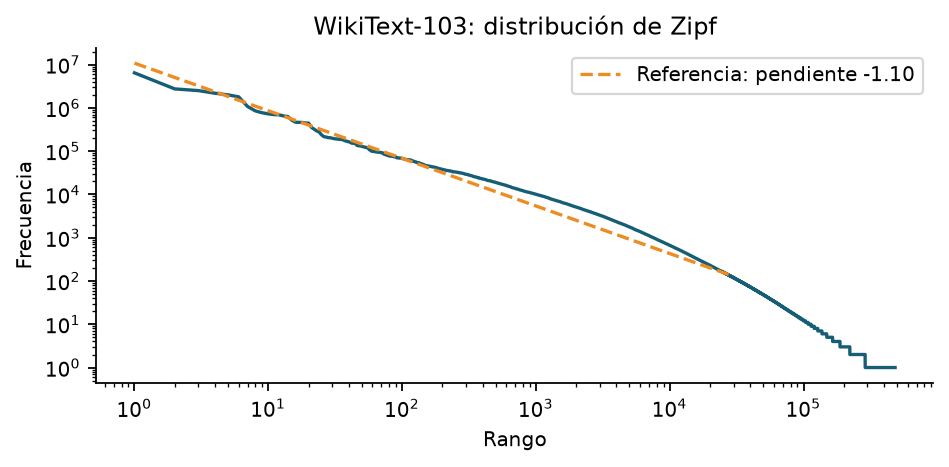

In [4]:
display(pd.DataFrame(prep['thresholds']))
display(pd.Series(prep['coverage_full_train'], name='Cobertura de tokens (%)'))
print('Pendiente log-log (rangos 100–10,000):', prep['zipf_slope_rank_100_10000'])
figura('zipf.png')


Zipf se observa aproximadamente en el tramo central; la pendiente cercana a -1 no implica cumplimiento exacto en todo el rango. Los umbrales se calculan sobre los 22M tokens antes de eliminar OOV; la cobertura top-k se calcula sobre todo train de WikiText. Son denominadores distintos y están etiquetados.

In [5]:
# Implementación completa de construcción del corpus, conteos e IDs en el repositorio.
from src.preprocessing import prepare
print(inspect.getsource(prepare))


def prepare(target=22_000_000,min_count=20):
    from datasets import load_from_disk
    data=load_from_disk(str(ROOT/'data/wikitext'))
    counts=Counter(); full=Counter(); lines=[]; subset_articles=0
    total=0; stats={}
    for split,ds in data.items():
        n_tokens=n_articles=n_nonempty=0
        for row in ds:
            text=row['text']; words=tokenize(text)
            n_articles+=bool(ARTICLE_RE.match(text)); n_nonempty+=bool(text.strip())
            n_tokens+=len(words)
            if split=='train':
                full.update(words)
                if total<target and words:
                    take=words[:target-total]
                    lines.append(take); counts.update(take); total+=len(take)
                    subset_articles+=bool(ARTICLE_RE.match(text))
        stats[split]={'lines':len(ds),'nonempty_lines':n_nonempty,'articles':n_articles,'tokens':n_tokens}
    words=sorted((w for w,n in counts.items() if n>=min_count),key=lambda w:(-counts[w],w))
    mapping

## 3. Investigación: PyTorch, gensim, CBOW, skip-gram y GloVe


`nn.Embedding(num_embeddings, embedding_dim, padding_idx=None, sparse=False)` guarda una matriz V × d y devuelve las filas indicadas por IDs. `num_embeddings` incluye todas las filas necesarias, y `embedding_dim` fija d. `padding_idx` excluye esa fila de los gradientes; su inicialización predeterminada es cero. `sparse=True` produce gradientes dispersos, no una tabla dispersa: la matriz de pesos sigue siendo densa. SGD y SparseAdam admiten estos gradientes; Adam estándar no. `nn.Embedding.from_pretrained(weights, freeze=True)` carga una matriz existente y controla si sus pesos se actualizan. La tokenización y el orden de IDs deben coincidir con las filas de la matriz.

Fuente: [PyTorch, Embedding y from_pretrained](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Embedding.html).

`nn.EmbeddingBag` agrega las filas de cada documento sin materializar un tensor completo con padding. Para entrada 1D, `offsets` contiene el índice inicial de cada documento. `mean` promedia, `sum` suma y `max` obtiene máximos por coordenada; este último no admite gradientes dispersos. Con `include_last_offset=True`, se agrega un offset final igual al número de tokens. Aquí se usa `mean`, `include_last_offset=False` y una fila de padding excluida. Un documento vacío se representa por UNK. El promedio pierde el orden y la longitud explícita del texto; el MLP recibe sólo d valores.

Fuente: [PyTorch, EmbeddingBag](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.sparse.EmbeddingBag.html).

## Skip-gram, CBOW y las dos matrices

CBOW predice la palabra central a partir de los contextos; skip-gram predice contextos a partir de la palabra central. SGNS usa una tabla de entrada W y una tabla de salida W': una palabra puede desempeñar ambos papeles, pero los parámetros cumplen funciones diferentes. Para un par positivo (c,o), se minimiza `-log σ(W_c · W'_o) - Σ log σ(-W_c · W'_n)`. Los negativos se muestrean con probabilidad proporcional a frecuencia^0.75. Se conserva W para las evaluaciones y la clasificación. W' sigue siendo necesaria durante el entrenamiento, aunque no se exporte como representación final.

Fuente: [Mikolov et al., 2013](https://arxiv.org/abs/1310.4546).

## Gensim

`Word2Vec` es la referencia: `sg=1` elige skip-gram; `vector_size`, `window`, `negative`, `sample`, `min_count`, `alpha`, `min_alpha`, `epochs` y `ns_exponent` controlan la dimensión, contexto, negativos, subsampling, vocabulario y optimización. `shrink_windows=False` fija la ventana para compararla con la implementación propia. `build_vocab_from_freq` recibe los mismos conteos filtrados y asegura un vocabulario idéntico. `train` recorre líneas tokenizadas y usa cuatro workers. La comparación conserva corpus, objetivo, dimensión, ventana, negativos, subsampling y calendario de tasa de aprendizaje; difieren el orden de actualización y el paralelismo: PyTorch suma gradientes por minibatch y gensim actualiza por pares con concurrencia. No se afirma identidad numérica.

`KeyedVectors` guarda vocabulario/vectores sin el estado del optimizador. `most_similar` resuelve vecinos y 3CosAdd; `most_similar_cosmul` implementa 3CosMul. `evaluate_word_analogies` y `evaluate_word_pairs` proporcionan evaluadores de referencia. El laboratorio usa además evaluadores propios para hacer explícitos candidatos, exclusiones, preguntas compartidas y cobertura. `api.load('glove-wiki-gigaword-100')` descarga el modelo preentrenado; `save_word2vec_format(..., binary=False)` exporta el mejor SGNS.

Fuentes: [Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html), [KeyedVectors](https://radimrehurek.com/gensim/models/keyedvectors.html).

## Word2Vec y GloVe

Word2Vec aprende predictivamente con pares de contexto; GloVe ajusta una función de mínimos cuadrados ponderados sobre conteos globales de coocurrencia. El modelo descargado tiene 400,000 palabras, 100 dimensiones y procede de Wikipedia 2014 + Gigaword 5, con 6,000 millones de tokens y texto en minúsculas. No se entrena adicionalmente para la comparación intrínseca. El fine-tuning downstream crea copias independientes y no modifica el GloVe de referencia. Las fuentes consultadas no proporcionan un tiempo y hardware inequívocos para este archivo concreto de 100 dimensiones: se reportan como no disponibles, sin trasladar mediciones de 300 dimensiones.

Fuentes: [GloVe, modelos originales](https://nlp.stanford.edu/projects/glove/), [Pennington et al., 2014](https://aclanthology.org/D14-1162/).



In [6]:
# Demostración de offsets y de mean/sum/max en EmbeddingBag.
W = torch.tensor([[0.,0.], [1.,2.], [3.,4.], [5.,6.]])
ids = torch.tensor([1, 2, 3])
offsets = torch.tensor([0, 2])  # documentos: [1,2] y [3]
for mode in ['mean', 'sum', 'max']:
    bag = nn.EmbeddingBag.from_pretrained(W, freeze=True, mode=mode, padding_idx=0)
    print(mode, bag(ids, offsets))
frozen = nn.Embedding.from_pretrained(W, freeze=True, padding_idx=0)
trainable = nn.Embedding.from_pretrained(W, freeze=False, padding_idx=0)
print('freeze=True requires_grad:', frozen.weight.requires_grad)
print('freeze=False requires_grad:', trainable.weight.requires_grad)


mean tensor([[2., 3.],
        [5., 6.]])
sum tensor([[4., 6.],
        [5., 6.]])
max tensor([[3., 4.],
        [5., 6.]])
freeze=True requires_grad: False
freeze=False requires_grad: True


## 4. SGNS propio: dos tablas y negative sampling
Para centro c y contexto o, se minimiza `-log sigmoid(W_c·W'_o) - Σ log sigmoid(-W_c·W'_n)`. Los negativos siguen f^0.75; cuando un negativo coincide con o se descarta, como en word2vec. Se usan gradientes dispersos y SGD sobre la suma del minibatch. Esto conserva la escala de actualizaciones por par, aunque no el orden online de gensim. La pérdida reportada se divide entre pares. W se exporta como representación final.

In [7]:
class SGNS(nn.Module):
    def __init__(self,vocab_size,dim,sparse=True):
        super().__init__()
        self.input=nn.Embedding(vocab_size,dim,sparse=sparse)
        self.output=nn.Embedding(vocab_size,dim,sparse=sparse)
        nn.init.uniform_(self.input.weight,-.5/dim,.5/dim)
        nn.init.zeros_(self.output.weight)
    def forward(self,center,context,negative):
        x=self.input(center);y=self.output(context);n=self.output(negative)
        positive=(x*y).sum(-1)
        negative_scores=(x[:,None,:]*n).sum(-1)
        # Igual que word2vec: descartar negativos que coinciden con el contexto positivo.
        mask=negative!=context[:,None]
        losses=-(nn.functional.logsigmoid(positive)+(nn.functional.logsigmoid(-negative_scores)*mask).sum(-1))
        return losses


### Subsampling y generación de pares
Se usa `min(1,(sqrt(f/t)+1)t/f)`, variante de word2vec/gensim. Primero se filtran OOV, luego se descartan apariciones y finalmente se construyen ventanas fijas. Cada epoch tiene una muestra nueva. La función de pares no cruza límites de líneas; produce todos los pares, sin un recorte arbitrario de pasos.

In [8]:
def keep_prob(counts,t=1e-5):
    f=counts/counts.sum()
    return np.minimum(1.0,(np.sqrt(f/t)+1)*t/f)

@njit(cache=False)
def generate_pairs(ids,offsets,window):
    n=0
    for i in range(len(offsets)-1):
        length=offsets[i+1]-offsets[i]
        for d in range(1,window+1):n+=2*max(0,length-d)
    pairs=np.empty((n,2),dtype=np.int32);p=0
    for line in range(len(offsets)-1):
        lo=offsets[line];hi=offsets[line+1]
        for pos in range(lo,hi):
            for ctx in range(max(lo,pos-window),min(hi,pos+window+1)):
                if pos!=ctx:
                    pairs[p,0]=ids[pos];pairs[p,1]=ids[ctx];p+=1
    return pairs


In [9]:
from src.sgns import train, subsample, CONFIGS, pair_count
print(inspect.getsource(subsample))
print(inspect.getsource(train))


def subsample(ids,offsets,counts,t,seed):
    rng=np.random.default_rng(seed);keep=rng.random(len(ids))<keep_prob(counts,t)[ids]
    lengths=np.add.reduceat(keep.astype(np.int32),offsets[:-1]); positive=lengths[lengths>0]
    new_offsets=np.r_[0,np.cumsum(positive,dtype=np.int64)]
    drops={w:{'discarded_percent':float(100*(1-keep[ids==i].mean())),'expected_percent':float(100*(1-keep_prob(counts,t)[i]))} for w,i in [(w,json.loads((ROOT/'data/vocab.json').read_text()).index(w)) for w in ['the','of','and']]}
    return ids[keep],new_offsets,drops

def train(config,candidates):
    name=config['name'];result_path=ROOT/'results'/f'sgns_{name}.json'
    if result_path.exists() and (ROOT/'models'/f'{name}.kv').exists() and len(json.loads(result_path.read_text())['records'])==config['epochs']:
        print('Ya entrenado',name,flush=True);return json.loads(result_path.read_text())
    torch.manual_seed(config['seed']);torch.set_num_threads(4)
    counts=np.load(ROOT/'data/counts.npy');words=

,name,dim,fraction,window,negative,epochs,min_count,sample,lr,min_lr,batch_size,seed,tokens,best_epoch,loss,accuracy_semantic,accuracy_syntactic,accuracy_total,wordsim,training_seconds
0,d100_k5,100,1.00,2,5,3,20,0.00001,0.025,0.001,1024,23045,21336925,3,2.262188,0.116163,0.169481,0.152789,0.562482,222.313233
1,d100_n100,100,1.00,2,3,3,20,0.00001,0.025,0.001,1024,23045,21336925,3,1.890991,0.093035,0.129836,0.118315,0.550774,206.262327
2,d100_n25,100,0.25,2,3,3,20,0.00001,0.025,0.001,1024,23045,5334231,3,2.171132,0.010512,0.007426,0.008392,0.137637,46.521107
3,d100_n50,100,0.50,2,3,3,20,0.00001,0.025,0.001,1024,23045,10668462,3,2.026102,0.021813,0.024554,0.023696,0.376434,94.630564
4,d100_w5,100,1.00,5,3,3,20,0.00001,0.025,0.001,1024,23045,21336925,3,1.844888,0.166097,0.265301,0.234244,0.650361,458.814827
5,d300_n100,300,1.00,2,3,3,20,0.00001,0.025,0.001,1024,23045,21336925,3,1.899351,0.088042,0.118457,0.108935,0.538913,292.094788
6,d50_n100,50,1.00,2,3,3,20,0.00001,0.025,0.001,1024,23045,21336925,3,1.888877,0.093561,0.124206,0.114612,0.545642,170.835332


Selección: {'best': 'd100_w5', 'best_100': 'd100_w5', 'criterion': 'Modelo principal: >=20M tokens conocidos. Spearman WordSim-353 + accuracy total de analogías compartidas; mejor epoch.', 'scores': {'d100_n100': 0.6690884951375047, 'd50_n100': 0.6602541051988813, 'd300_n100': 0.6478486048407811, 'd100_n25': 0.14602926708262942, 'd100_n50': 0.4001301446242885, 'd100_w5': 0.884604697146811, 'd100_k5': 0.7152708912655381}}
Epoch 1 pérdida 2.053632864178992 pares antes/después 205575606 64745108 tiempo train 151.3022442079964 GPU pico bytes 0
Epoch 2 pérdida 1.8834057185352968 pares antes/después 205575606 64741052 tiempo train 151.40137537498958 GPU pico bytes 0
Epoch 3 pérdida 1.8448881140258342 pares antes/después 205575606 64740032 tiempo train 156.11120779201156 GPU pico bytes 0


,discarded_percent,expected_percent
the,98.827958,98.841399
of,98.228525,98.221561
and,98.142906,98.133607


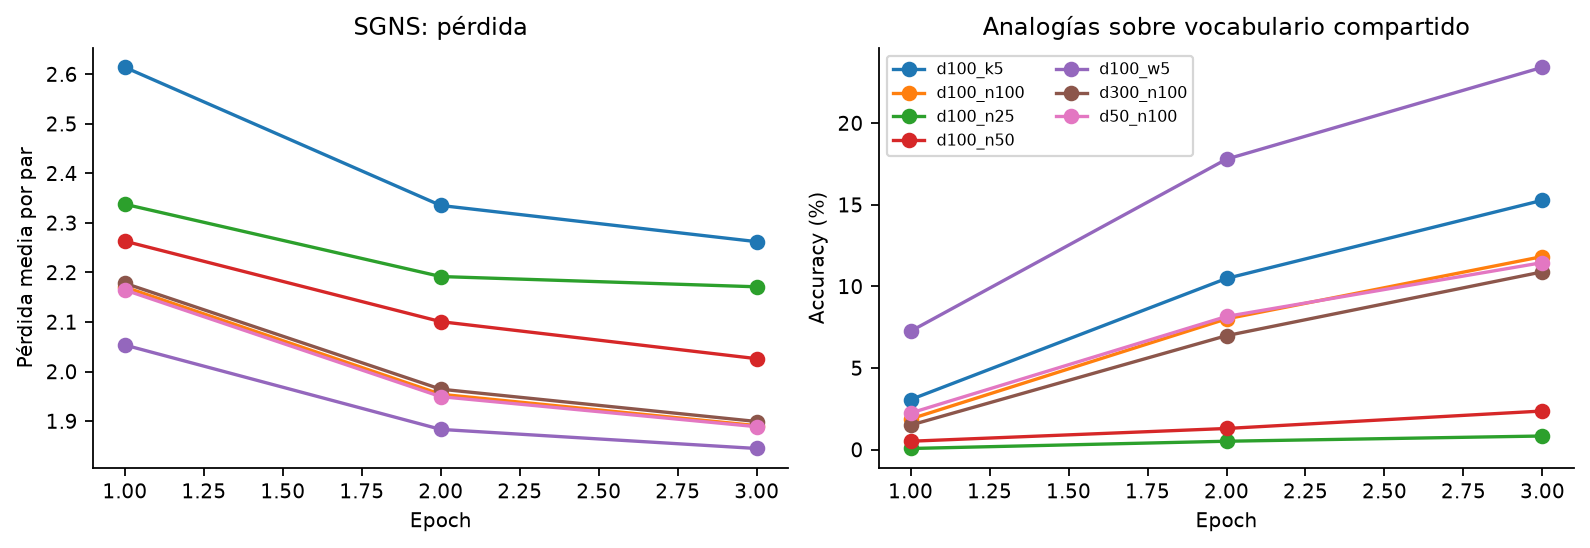

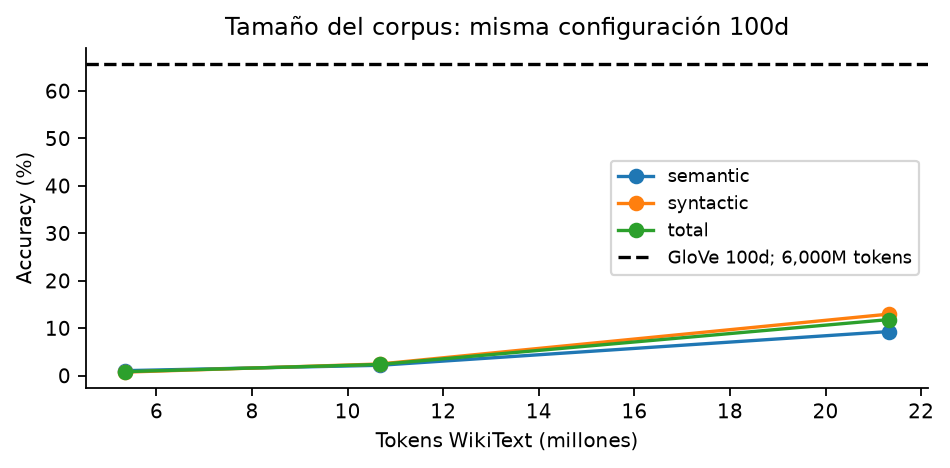

In [10]:
iterations = pd.read_csv(ROOT / 'results/iterations.csv')
display(iterations)
selection = resultado('selection.json')
print('Selección:', selection)
sgns_run = resultado('sgns_' + selection['best'] + '.json')
for record in sgns_run['records']:
    print('Epoch', record['epoch'], 'pérdida', record['loss'],
          'pares antes/después', record['pairs_before_subsampling'], record['pairs_after_subsampling'],
          'tiempo train', record['train_seconds'], 'GPU pico bytes', record['gpu_peak_bytes'])
display(pd.DataFrame(sgns_run['records'][-1]['subsampling']).T)
figura('curvas_embeddings.png')
figura('analogias_vs_tokens.png')


La selección sólo usa WS353 y questions-words: score = Spearman + accuracy total. El modelo principal es el mejor entre configuraciones con >=20M tokens conocidos; se identifica además el mejor de 100 dimensiones. SimLex no participa. La pérdida SGNS no optimiza directamente accuracy de analogías; cambiar k cambia su escala y no permite comparaciones directas de pérdida.

In [11]:
# Métricas, vecinos fijos y tiempos de CADA configuración y CADA epoch.
for path in sorted((ROOT / 'results').glob('sgns_*.json')):
    run = json.loads(path.read_text())
    print('\nConfiguración:', run['config'])
    display(pd.DataFrame([{'epoch':r['epoch'], 'loss':r['loss'],
        'semantic':r['analogies']['accuracy']['semantic'],
        'syntactic':r['analogies']['accuracy']['syntactic'],
        'total':r['analogies']['accuracy']['total'],
        'WS353':r['wordsim']['spearman'], 'train_seconds':r['train_seconds'],
        'evaluation_seconds':r['evaluation_seconds'], 'gpu_peak_bytes':r['gpu_peak_bytes']}
        for r in run['records']]))
    for r in run['records']:
        print('Epoch', r['epoch'], 'vecinos:')
        display(pd.DataFrame(r['neighbors']).T)



Configuración: {'name': 'd100_k5', 'dim': 100, 'fraction': 1.0, 'window': 2, 'negative': 5, 'epochs': 3, 'min_count': 20, 'sample': 1e-05, 'lr': 0.025, 'min_lr': 0.001, 'batch_size': 1024, 'seed': 23045}


,epoch,loss,semantic,syntactic,total,WS353,train_seconds,evaluation_seconds,gpu_peak_bytes
0,1,2.614039,0.032063,0.030063,0.030689,0.408959,73.814372,0.311711,0
1,2,2.335225,0.087779,0.112708,0.104904,0.533784,74.090712,0.454650,0
2,3,2.262188,0.116163,0.169481,0.152789,0.562482,74.408149,0.318565,0


Epoch 1 vecinos:


,0,1,2,3,4
king,"[throne, 0.9483181238174438]","[emperor, 0.9323840737342834]","[heir, 0.9319251775741577]","[pope, 0.9254275560379028]","[philip, 0.9254178404808044]"
france,"[austria, 0.9635884761810303]","[italy, 0.9629427790641785]","[spain, 0.9610936641693115]","[netherlands, 0.9607672095298767]","[russia, 0.9579598903656006]"
computer,"[software, 0.9738031625747681]","[hardware, 0.964277446269989]","[graphics, 0.9474971294403076]","[modes, 0.9466162919998169]","[gameplay, 0.9424374103546143]"
good,"[excited, 0.9807653427124023]","[cry, 0.9756292700767517]","[bigger, 0.9755563139915466]","[hadn, 0.9746145009994507]","[anymore, 0.9743271470069885]"
january,"[february, 0.967897891998291]","[march, 0.9673036932945251]","[april, 0.964537501335144]","[december, 0.9621642827987671]","[june, 0.9609034061431885]"
run,"[rush, 0.936723530292511]","[hokies, 0.9200078845024109]","[running, 0.9170831441879272]","[vick, 0.9096999168395996]","[offense, 0.9065656661987305]"


Epoch 2 vecinos:


...

,0,1,2,3,4
king,"[lord, 0.9460150003433228]","[catherine, 0.9448139667510986]","[throne, 0.9443020224571228]","[pope, 0.9438557624816895]","[heir, 0.9435850381851196]"
france,"[italy, 0.9643617272377014]","[spain, 0.9557068347930908]","[greece, 0.9553400874137878]","[austria, 0.9489802718162537]","[germany, 0.9484863877296448]"
computer,"[hardware, 0.9694613218307495]","[gameplay, 0.955371618270874]","[software, 0.9541633129119873]","[graphics, 0.9514185190200806]","[product, 0.9495765566825867]"
good,"[fun, 0.9795727729797363]","[liked, 0.9742615222930908]","[cry, 0.9736139178276062]","[definitely, 0.9715219140052795]","[everything, 0.9706323146820068]"
january,"[march, 0.9812219142913818]","[december, 0.9714655876159668]","[april, 0.9699376225471497]","[february, 0.9677035808563232]","[november, 0.9659776091575623]"
run,"[yard, 0.927825391292572]","[touchdown, 0.9272944927215576]","[trent, 0.9196942448616028]","[running, 0.9183284640312195]","[pass, 0.9132876992225647]"


Epoch 2 vecinos:


,0,1,2,3,4
king,"[throne, 0.8927661180496216]","[prince, 0.8694674968719482]","[emperor, 0.8610427379608154]","[heir, 0.8557040691375732]","[reign, 0.8492938876152039]"
france,"[italy, 0.9380800127983093]","[spain, 0.9342575669288635]","[netherlands, 0.928305447101593]","[austria, 0.9220208525657654]","[portugal, 0.9167208075523376]"
computer,"[hardware, 0.9417147636413574]","[computers, 0.927890419960022]","[developers, 0.9166051149368286]","[graphical, 0.9103583097457886]","[user, 0.9099809527397156]"
good,"[definitely, 0.9167059063911438]","[exciting, 0.9121958613395691]","[doing, 0.9044913053512573]","[better, 0.8904440999031067]","[pretty, 0.8893656134605408]"
january,"[february, 0.9720206260681152]","[june, 0.9632579684257507]","[november, 0.9626346826553345]","[march, 0.9614819884300232]","[december, 0.9596689343452454]"
run,"[running, 0.8580317497253418]","[ran, 0.8576008081436157]","[deshazo, 0.8442507982254028]","[punting, 0.8411885499954224]","[druckenmiller, 0.8338404297828674]"


Epoch 3 vecinos:


,0,1,2,3,4
king,"[prince, 0.8931917548179626]","[throne, 0.8850111365318298]","[heir, 0.8474322557449341]","[consort, 0.8418958783149719]","[pope, 0.8392135500907898]"
france,"[italy, 0.9224621057510376]","[spain, 0.9212180376052856]","[netherlands, 0.9024751782417297]","[austria, 0.8985430598258972]","[belgium, 0.8819366097450256]"
computer,"[hardware, 0.9317988157272339]","[computers, 0.9124146103858948]","[graphical, 0.912406861782074]","[handheld, 0.9053452014923096]","[user, 0.8998724818229675]"
good,"[definitely, 0.892714262008667]","[exciting, 0.8899145126342773]","[doing, 0.8761215209960938]","[bad, 0.8754518628120422]","[pretty, 0.8653203845024109]"
january,"[february, 0.975036084651947]","[december, 0.9712348580360413]","[march, 0.9691348075866699]","[november, 0.9680754542350769]","[april, 0.9649490118026733]"
run,"[running, 0.8722413778305054]","[ran, 0.8470581769943237]","[scrimmage, 0.8361132144927979]","[yardage, 0.8324234485626221]","[punting, 0.8305022120475769]"


### Referencia gensim y GloVe
La referencia gensim emplea `sg=1`, `hs=0`, `shrink_windows=False`, el mismo corpus/vocabulario y valores de dimensión, ventana, negativos, sample, LR y epochs del mejor SGNS. Usa cuatro workers y actualizaciones online, por lo que no se afirma equivalencia numérica de la optimización. La pérdida de gensim es un acumulador aproximado y no está en la escala de la media SGNS.

GloVe se carga sin entrenamiento adicional. Los pesos originales se conservan para evaluar; fine-tuning de clasificación usa copias. El tiempo/hardware original del archivo exacto 100d no aparece inequívocamente en las fuentes consultadas y se deja N/D.

In [12]:
print((ROOT / 'scripts/reference_and_final.py').read_text())
ref = resultado('gensim_training.json')
for record in ref['records']:
    print('Epoch', record['epoch'], 'analogías:', record['analogies']['accuracy'],
          'WS353:', record['wordsim'], 'segundos:', record['train_seconds'])
    display(pd.DataFrame(record['neighbors']).T)


import sys,json,time,shutil
from pathlib import Path
sys.path.insert(0,str(Path(__file__).resolve().parents[1]))
import numpy as np
from gensim.models import Word2Vec,KeyedVectors
from gensim.models.word2vec import LineSentence
from src.preprocessing import ROOT,dump_json
from src.evaluation import benchmark,similarity,individual,CONTROL

selection=json.loads((ROOT/'results/selection.json').read_text())
name=selection['best'];r=json.loads((ROOT/'results'/f'sgns_{name}.json').read_text());c=r['config']
words=json.loads((ROOT/'data/vocab.json').read_text());counts=np.load(ROOT/'data/counts.npy')
candidates=json.loads((ROOT/'results/shared_vocab.json').read_text())
corpus=LineSentence(str(ROOT/'data/corpus.txt'),max_sentence_length=10**9)
result_path=ROOT/'results/gensim_training.json'
if not result_path.exists() or not (ROOT/'models/gensim.kv').exists():
 model=Word2Vec(vector_size=c['dim'],window=c['window'],min_count=c['min_count'],sg=1,hs=0,negative=c['negative'],ns_exponent=.75,sampl

,0,1,2,3,4
king,"[lfhelm, 0.8367646336555481]","[judith, 0.8294195532798767]","[thelred, 0.8263248205184937]","[earls, 0.8262253403663635]","[duke, 0.8261798620223999]"
france,"[spain, 0.8728531002998352]","[italy, 0.8642371296882629]","[netherlands, 0.8446381688117981]","[belgium, 0.8435709476470947]","[portugal, 0.8367043733596802]"
computer,"[simulation, 0.8818621635437012]","[hardware, 0.8779812455177307]","[computers, 0.8635417819023132]","[devices, 0.8621802926063538]","[zx, 0.8566226363182068]"
good,"[wonderful, 0.8723366260528564]","[incredible, 0.868852972984314]","[pretty, 0.8647122383117676]","[definitely, 0.8635520339012146]","[summed, 0.8628404140472412]"
january,"[february, 0.864537239074707]","[december, 0.8644795417785645]","[march, 0.8562556505203247]","[april, 0.8446085453033447]","[july, 0.8338059782981873]"
run,"[running, 0.8054041266441345]","[motorist, 0.78488689661026]","[swapped, 0.7706666588783264]","[weekends, 0.7669658660888672]","[flipped, 0.7635746598243713]"


Epoch 2 analogías: {'semantic': 0.10617608409986859, 'syntactic': 0.15798299197508683, 'total': 0.1417640283034392} WS353: {'spearman': 0.6040143447221464, 'evaluated': 344, 'total': 353, 'coverage': 0.9745042492917847} segundos: 15.011915499984752


,0,1,2,3,4
king,"[thelred, 0.7874760031700134]","[cnut, 0.7841113805770874]","[throne, 0.7823181748390198]","[thelbald, 0.7819651961326599]","[conqueror, 0.7789013385772705]"
france,"[netherlands, 0.8078675866127014]","[spain, 0.8025344014167786]","[belgium, 0.7844371795654297]","[italy, 0.7505813837051392]","[portugal, 0.7365754246711731]"
computer,"[computers, 0.8631809949874878]","[software, 0.8375476598739624]","[programmer, 0.8126550912857056]","[blackley, 0.8094925284385681]","[hitman, 0.8081682920455933]"
good,"[pretty, 0.8361865282058716]","[hasn, 0.8343077898025513]","[damn, 0.8255342841148376]","[awful, 0.820895254611969]","[aren, 0.8201568126678467]"
january,"[december, 0.8701837658882141]","[march, 0.8499588966369629]","[february, 0.8230066895484924]","[april, 0.8202086091041565]","[november, 0.8166166543960571]"
run,"[reverting, 0.6715222001075745]","[lytle, 0.6696279048919678]","[running, 0.6679880023002625]","[suggs, 0.6613354682922363]","[capitalized, 0.6541765332221985]"


Epoch 3 analogías: {'semantic': 0.14612352168199738, 'syntactic': 0.25943226733740565, 'total': 0.22395919038999507} WS353: {'spearman': 0.6377982201359133, 'evaluated': 344, 'total': 353, 'coverage': 0.9745042492917847} segundos: 13.56919020897476


,0,1,2,3,4
king,"[throne, 0.7647279500961304]","[1121, 0.7564148902893066]","[thelred, 0.7524538636207581]","[1136, 0.7493699789047241]","[regent, 0.7485096454620361]"
france,"[spain, 0.8151857852935791]","[netherlands, 0.8106077909469604]","[portugal, 0.7677130699157715]","[belgium, 0.7666090726852417]","[italy, 0.7493759989738464]"
computer,"[computers, 0.8653610348701477]","[simulation, 0.8185442090034485]","[spacewar, 0.8152511715888977]","[software, 0.8015428185462952]","[unix, 0.7974230647087097]"
good,"[pretty, 0.7900639772415161]","[obviously, 0.7823641300201416]","[aren, 0.781166136264801]","[hasn, 0.7808719277381897]","[natured, 0.7776313424110413]"
january,"[december, 0.9288539290428162]","[february, 0.9206566214561462]","[march, 0.9122180342674255]","[november, 0.900735080242157]","[april, 0.8729256391525269]"
run,"[running, 0.6783150434494019]","[suggs, 0.6713240146636963]","[ran, 0.6552290320396423]","[timeout, 0.6540025472640991]","[keldorf, 0.6531543731689453]"


## 5. Analogías propias, 3CosAdd, 3CosMul y paralelismo
`analogia(a,b,c,k)` resuelve a:b :: c:?. Normaliza individualmente a,b,c, normaliza la suma y excluye las tres palabras. Esto coincide con `most_similar(positive=[b,c], negative=[a])`. No se confunde con normalizar sólo una suma de vectores crudos.

In [13]:
def unit(x):
    x=np.asarray(x,dtype=np.float32)
    return x/np.maximum(np.linalg.norm(x,axis=-1,keepdims=True),1e-12)

def analogia(kv,a,b,c,k=5,exclude=True,candidates=None):
    """a:b :: c:?; 3CosAdd usa -unit(a)+unit(b)+unit(c), igual a most_similar."""
    keys=kv.index_to_key if candidates is None else candidates
    matrix=unit(kv.vectors) if candidates is None else unit(np.stack([kv[w] for w in keys]))
    q=unit(-unit(kv[a])+unit(kv[b])+unit(kv[c])); scores=matrix@q
    if exclude:
        ids={w:i for i,w in enumerate(keys)}
        for w in {a,b,c}:
            if w in ids:scores[ids[w]]=-np.inf
    order=np.argsort(-scores)[:min(k,int(np.isfinite(scores).sum()))]
    return [(keys[i],float(scores[i])) for i in order]


In [14]:
from gensim.models import KeyedVectors
from src.evaluation import benchmark, individual, similarity
sgns = KeyedVectors.load(str(ROOT / 'models' / (selection['best'] + '.kv'))) if (ROOT / 'models' / (selection['best'] + '.kv')).exists() else KeyedVectors.load_word2vec_format(str(ROOT / 'models/mejor_sgns.txt'))
print(analogia(sgns, 'man', 'woman', 'king', 5))
print(sgns.most_similar(positive=['woman','king'], negative=['man'], topn=5))
final = resultado('embedding_final.json')
for name, result in final.items():
    assert result['individual']['matches_gensim_all']
    print(name, 'coincidencia verificada con gensim:', result['individual']['matches_gensim_all'])


[('consort', 0.7051764726638794), ('marriage', 0.6880382299423218), ('childless', 0.6849664449691772), ('sibyl', 0.6821231842041016), ('violante', 0.6667181849479675)]
[('consort', 0.7051764726638794), ('marriage', 0.6880382895469666), ('childless', 0.684966504573822), ('sibyl', 0.6821231842041016), ('violante', 0.6667181253433228)]
SGNS coincidencia verificada con gensim: True
gensim coincidencia verificada con gensim: True
GloVe coincidencia verificada con gensim: True


In [15]:
# 21 consultas × 3 modelos, con top-5/scores, rango correcto y sin exclusión.
for name, result in final.items():
    print('\nModelo:', name)
    rows = result['individual']['queries']
    display(pd.DataFrame(rows)[['type','a','b','c','expected','top5','expected_rank',
                               'expected_cosine','without_exclusion','difference_cosine','relative_residual']])



Modelo: SGNS


,type,a,b,c,expected,top5,expected_rank,expected_cosine,without_exclusion,difference_cosine,relative_residual
0,genero,man,woman,king,queen,"[[consort, 0.7051764726638794], [marriage, 0.6...",28,0.638616,"[[king, 0.7234075665473938], [consort, 0.70517...",0.348146,0.571216
1,genero,boy,girl,brother,sister,"[[wed, 0.7380378842353821], [fathered, 0.71102...",787,0.525906,"[[brother, 0.7665119171142578], [wed, 0.738037...",0.116038,0.665807
2,genero,father,mother,son,daughter,"[[daughter, 0.7941516637802124], [fathered, 0....",1,0.794152,"[[mother, 0.8538044691085815], [son, 0.7974047...",0.427446,0.535083
3,capital,france,paris,germany,berlin,"[[berlin, 0.8144534826278687], [vienna, 0.7567...",1,0.814453,"[[berlin, 0.8144534826278687], [vienna, 0.7567...",0.654170,0.416962
4,capital,italy,rome,japan,tokyo,"[[ryse, 0.6601597666740417], [empires, 0.65081...",33,0.584580,"[[japan, 0.6947208642959595], [ryse, 0.6601597...",0.273008,0.603537
5,capital,spain,madrid,england,london,"[[burnley, 0.7668814659118652], [gillingham, 0...",1454,0.436797,"[[burnley, 0.7668814659118652], [gillingham, 0...",0.218729,0.626126
6,gentilicio,france,french,germany,german,"[[german, 0.7775048017501831], [russian, 0.765...",1,0.777505,"[[german, 0.7775048017501831], [russian, 0.765...",0.645664,0.420969
7,gentilicio,japan,japanese,china,chinese,"[[chinese, 0.818138837814331], [sino, 0.642905...",1,0.818139,"[[chinese, 0.818138837814331], [china, 0.74843...",0.624538,0.433403
8,gentilicio,italy,italian,spain,spanish,"[[spanish, 0.7942861914634705], [portuguese, 0...",1,0.794286,"[[italian, 0.7978676557540894], [spanish, 0.79...",0.663223,0.410895
9,comparativo,good,better,bad,worse,"[[deviated, 0.6376618146896362], [weren, 0.628...",93,0.551139,"[[better, 0.7369165420532227], [bad, 0.7297984...",0.303013,0.597718



Modelo: gensim


,type,a,b,c,expected,top5,expected_rank,expected_cosine,without_exclusion,difference_cosine,relative_residual
0,genero,man,woman,king,queen,"[[marriage, 0.6817952394485474], [consort, 0.6...",39,0.606895,"[[king, 0.7126541137695312], [marriage, 0.6817...",0.280972,0.599614
1,genero,boy,girl,brother,sister,"[[fathered, 0.7394896745681763], [cousin, 0.71...",298,0.560057,"[[brother, 0.7409980297088623], [fathered, 0.7...",0.243936,0.616114
2,genero,father,mother,son,daughter,"[[daughter, 0.798553466796875], [stillborn, 0....",1,0.798553,"[[mother, 0.8577408790588379], [son, 0.8339000...",0.340830,0.574319
3,capital,france,paris,germany,berlin,"[[berlin, 0.8266746997833252], [moscow, 0.7239...",1,0.826675,"[[berlin, 0.8266746997833252], [germany, 0.728...",0.658836,0.413038
4,capital,italy,rome,japan,tokyo,"[[ryse, 0.671877920627594], [playstation, 0.64...",141,0.531986,"[[ryse, 0.671877920627594], [japan, 0.67050242...",0.192070,0.637370
5,capital,spain,madrid,england,london,"[[fixture, 0.7626079320907593], [stoke, 0.7613...",1068,0.449566,"[[fixture, 0.7626079320907593], [stoke, 0.7613...",0.163940,0.647187
6,gentilicio,france,french,germany,german,"[[german, 0.7561564445495605], [russian, 0.728...",1,0.756156,"[[german, 0.7561564445495605], [russian, 0.728...",0.579315,0.459799
7,gentilicio,japan,japanese,china,chinese,"[[chinese, 0.7775830030441284], [java, 0.66275...",1,0.777583,"[[chinese, 0.7775830030441284], [china, 0.7047...",0.568347,0.467766
8,gentilicio,italy,italian,spain,spanish,"[[spanish, 0.7519546747207642], [espa, 0.74219...",1,0.751955,"[[italian, 0.8237107992172241], [spanish, 0.75...",0.647002,0.420425
9,comparativo,good,better,bad,worse,"[[bigger, 0.617207944393158], [wanting, 0.5722...",16,0.516751,"[[better, 0.7333896160125732], [bad, 0.7187108...",0.219251,0.625881



Modelo: GloVe


,type,a,b,c,expected,top5,expected_rank,expected_cosine,without_exclusion,difference_cosine,relative_residual
0,genero,man,woman,king,queen,"[[queen, 0.7698540687561035], [monarch, 0.6843...",1,0.769854,"[[king, 0.8360679745674133], [queen, 0.7698540...",0.450996,0.533801
1,genero,boy,girl,brother,sister,"[[daughter, 0.8896641731262207], [wife, 0.8840...",6,0.840476,"[[brother, 0.9152929782867432], [daughter, 0.8...",0.639054,0.485377
2,genero,father,mother,son,daughter,"[[daughter, 0.9525263905525208], [wife, 0.8872...",1,0.952526,"[[daughter, 0.9525263905525208], [mother, 0.92...",0.823345,0.297758
3,capital,france,paris,germany,berlin,"[[berlin, 0.8846380710601807], [frankfurt, 0.7...",1,0.884638,"[[berlin, 0.8846380710601807], [frankfurt, 0.7...",0.782346,0.330018
4,capital,italy,rome,japan,tokyo,"[[tokyo, 0.7762304544448853], [beijing, 0.6690...",1,0.776230,"[[tokyo, 0.7762304544448853], [japan, 0.672163...",0.632434,0.430451
5,capital,spain,madrid,england,london,"[[manchester, 0.8262482285499573], [leeds, 0.8...",16,0.659869,"[[manchester, 0.8262482285499573], [leeds, 0.8...",0.388967,0.555950
6,gentilicio,france,french,germany,german,"[[german, 0.9596726894378662], [austrian, 0.77...",1,0.959673,"[[german, 0.9596726894378662], [germany, 0.796...",0.902571,0.221979
7,gentilicio,japan,japanese,china,chinese,"[[chinese, 0.9533727169036865], [taiwanese, 0....",1,0.953373,"[[chinese, 0.9533727169036865], [china, 0.8064...",0.874215,0.252288
8,gentilicio,italy,italian,spain,spanish,"[[spanish, 0.9227449893951416], [french, 0.753...",1,0.922745,"[[spanish, 0.9227449893951416], [italian, 0.78...",0.840033,0.283455
9,comparativo,good,better,bad,worse,"[[worse, 0.8442931175231934], [too, 0.74913650...",1,0.844293,"[[bad, 0.8963202238082886], [worse, 0.84429311...",0.526278,0.501052


### Benchmark compartido y análisis de desplazamientos
Se toman las 30,000 palabras más frecuentes de WikiText presentes en SGNS, gensim y GloVe. Sólo se evalúan preguntas cuyas cuatro palabras pertenecen a esa lista. Tanto preguntas como candidatos coinciden entre modelos. Cobertura = preguntas evaluadas / 19,544. Accuracy es sobre las evaluadas; no cuenta OOV como errores.

La guía remite a una sección 5.3 ausente. Para cumplir el entregable de paralelismo se incluyen cos(v_b-v_a, v_d-v_c) y residuo relativo de esos desplazamientos sobre vectores crudos. Un coseno cercano a 1 implica dirección parecida, pero no magnitud igual; un ranking correcto tampoco demuestra igualdad algebraica.

def benchmark(kv,candidates,methods=('add',),batch=256):
    """Misma lista de candidatos y preguntas; no evaluar consultas parcialmente OOV."""
    keys={w:i for i,w in enumerate(candidates)}
    matrix=unit(np.stack([kv[w] for w in candidates])); questions=read_analogies()
    qs=[q for q in questions if all(w in keys for w in q[1:])]
    indices=np.asarray([[keys[w] for w in q[1:]] for q in qs],dtype=int)
    cats=list(dict.fromkeys(q[0] for q in questions));out={}
    totals={cat:sum(q[0]==cat for q in questions) for cat in cats}
    # BLAS por lotes: memoria O(batch*V), no O(preguntas*V).
    for method in methods:
        correct=np.zeros(len(qs),dtype=bool)
        for start in range(0,len(qs),batch):
            ids=indices[start:start+batch];a,b,c,d=ids.T
            if method=='add':scores=unit(-matrix[a]+matrix[b]+matrix[c])@matrix.T
            else:
                ca=(matrix[a]@matrix.T+1)/2; cb=(matrix[b]@matrix.T+1)/2; cc=(matrix[c]@matrix.T+1)/2
                scores=

,model,method,category,total,evaluated,coverage,correct,accuracy
0,SGNS,add,capital-common-countries,506,462,0.913043,122,0.264069
1,SGNS,add,capital-world,4524,1206,0.266578,245,0.203151
2,SGNS,add,currency,866,108,0.124711,1,0.009259
3,SGNS,add,city-in-state,2467,1687,0.683827,182,0.107884
4,SGNS,add,family,506,342,0.675889,82,0.239766
...,...,...,...,...,...,...,...,...
79,GloVe,mul,gram5-present-participle,1056,870,0.823864,628,0.721839
80,GloVe,mul,gram6-nationality-adjective,1599,1299,0.812383,1245,0.958430
81,GloVe,mul,gram7-past-tense,1560,1406,0.901282,773,0.549787
82,GloVe,mul,gram8-plural,1332,992,0.744745,748,0.754032


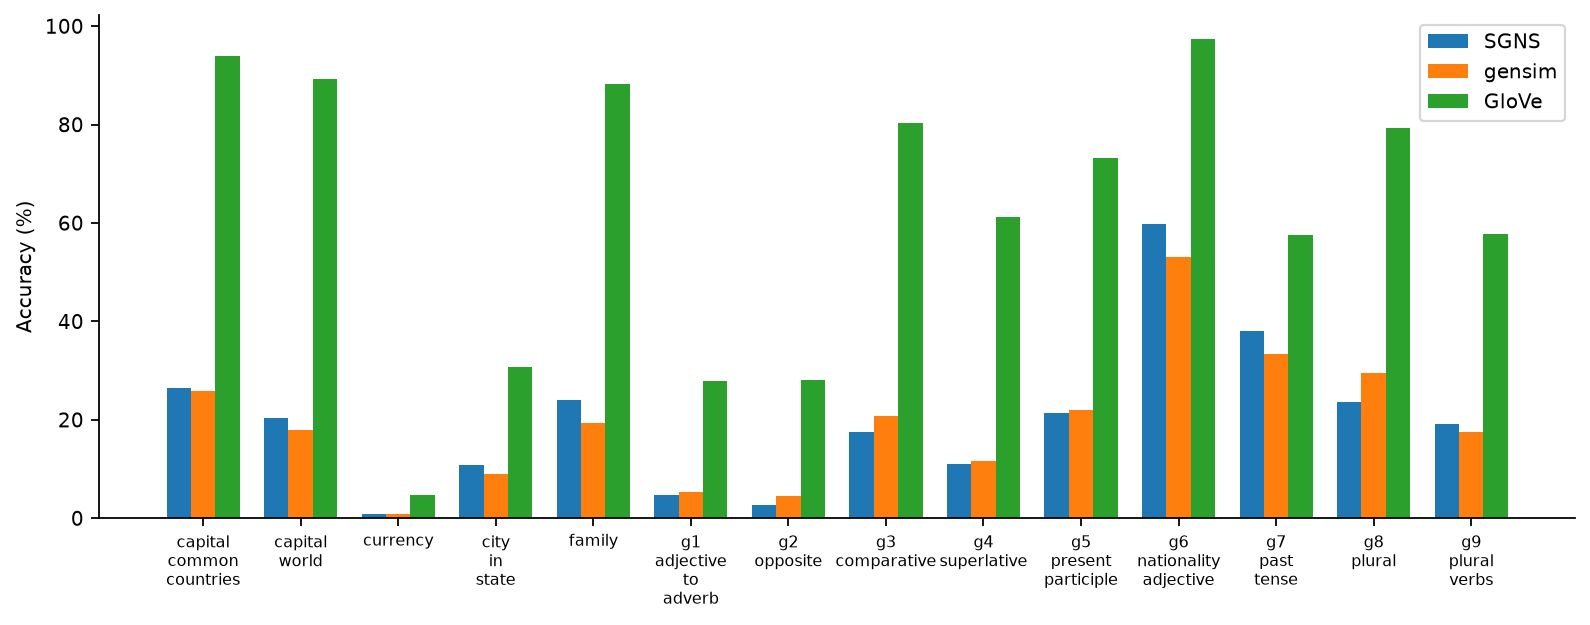

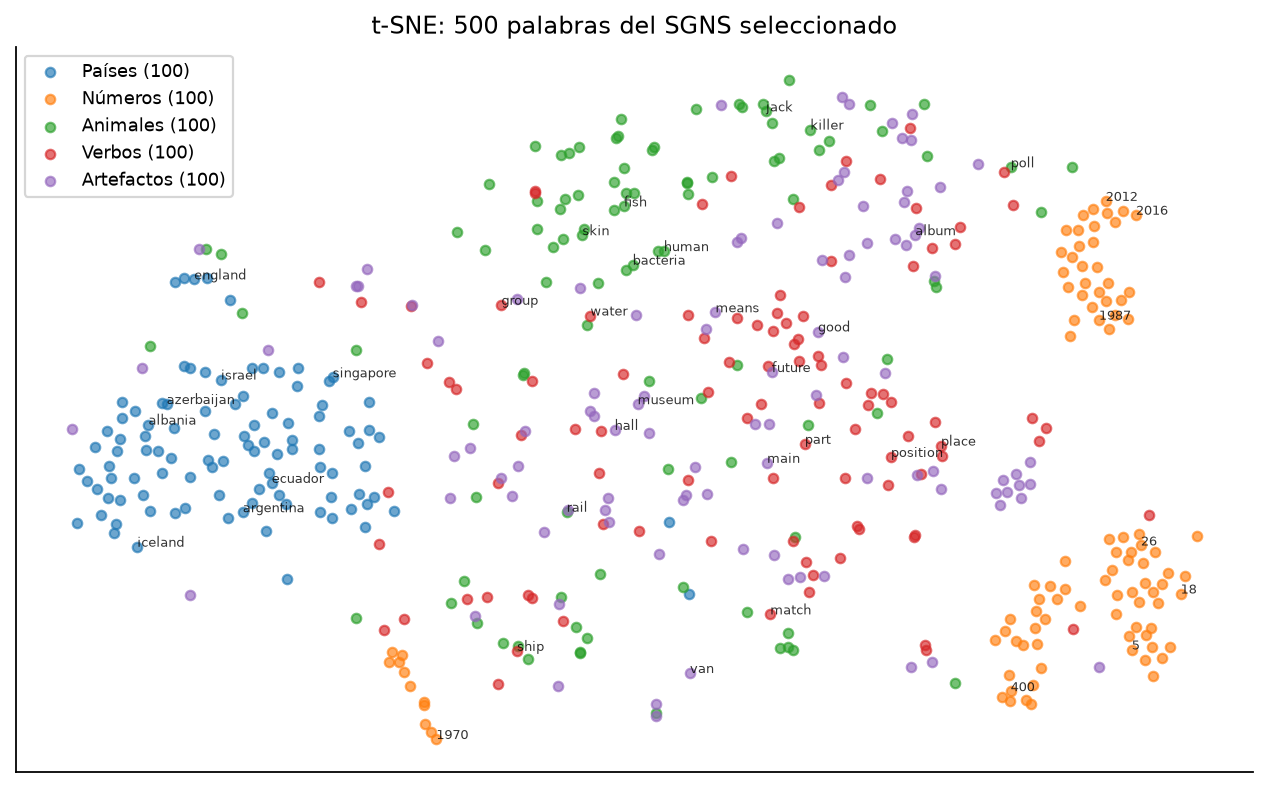

Palabras t-SNE: 500


In [16]:
print(inspect.getsource(benchmark))
for name, result in final.items():
    print(name, 'paralelismo medio:', result['individual']['parallelism_mean'])
    for method, ev in result['analogies'].items():
        print(method, ev['accuracy'], 'cobertura:', ev['evaluated'], '/', ev['total_questions'])
display(pd.read_csv(ROOT / 'results/benchmark_categories.csv'))
figura('analogias_categorias.png')
figura('tsne.png')
print('Palabras t-SNE:', len(resultado('tsne_words.json')))


t-SNE usa 500 vectores unitarios, perplexity=30 y semilla fija. Los grupos se definen antes de proyectar con países, números y categorías WordNet. Se observan agrupamientos parciales y solapamientos; polisemia y distorsión 2D impiden tratar la figura como prueba cuantitativa. La selección exacta y coordenadas se conservan en `tsne_words.json`.

## 6. Clasificación de AG News
108,000 train y 12,000 validación, estratificados; 7,600 test oficial. Se prueban TF-IDF + regresión logística, EmbeddingBag aleatorio entrenable, y SGNS/GloVe congelados y con fine-tuning. Se añade gensim como control para completar su F1 downstream.

El vocabulario de tarea se construye sólo con train, frecuencia mínima 2. Cada fuente conserva cobertura propia; los tokens sin vector se mapean a UNK. Se distinguen OOV del embedding y UNK de la tabla de tarea. Arquitectura MLP 128/ReLU/dropout 0.2/4 clases; 10 epochs, batch 512, Adam y SparseAdam a 0.003. Random usa la dimensión SGNS; otras fuentes usan su dimensión nativa. El input cambia si el SGNS elegido tiene dimensión distinta de 100, una limitación reportada.

Se seleccionan epochs y variantes por F1 macro de validación. Sólo al terminar toda selección se abre test; cada ganador por inicialización y fracción se evalúa una vez. La curva de datos utiliza un modelo diferente por fracción, no ajustes repetidos de un modelo mirando test. El vocabulario de tarea permanece fijo en fracciones menores y usa texto no etiquetado del train completo; TF-IDF se ajusta sólo con la fracción correspondiente.

In [17]:
class NewsClassifier(nn.Module):
    def __init__(self,weights,freeze=False):
        super().__init__()
        self.emb=nn.EmbeddingBag.from_pretrained(torch.as_tensor(weights),freeze=freeze,mode='mean',sparse=not freeze,padding_idx=0)
        self.mlp=nn.Sequential(nn.Linear(weights.shape[1],128),nn.ReLU(),nn.Dropout(.2),nn.Linear(128,4))
    def forward(self,ids,offsets):return self.mlp(self.emb(ids,offsets))

def collate(rows):
    lengths=[len(ids) for ids,label in rows]
    offsets=torch.tensor(np.r_[0,np.cumsum(lengths[:-1])],dtype=torch.long)
    ids=torch.tensor(np.concatenate([ids for ids,label in rows]),dtype=torch.long)
    return ids,offsets,torch.tensor([label for ids,label in rows],dtype=torch.long)


In [18]:
from src.classification import train_network, run
print(inspect.getsource(train_network))
print(inspect.getsource(run))


/Users/javiervalladares/.cache/lab7-embeddings-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


def train_network(weights,freeze,train_rows,val_rows,name,epochs=10):
    path=ROOT/'results'/f'clf_{name}.json';checkpoint=ROOT/'models'/f'clf_{name}.pt'
    if path.exists() and checkpoint.exists():return json.loads(path.read_text())
    torch.manual_seed(SEED);torch.set_num_threads(4)
    model=NewsClassifier(weights.copy(),freeze)
    head=torch.optim.Adam(model.mlp.parameters(),lr=.003)
    embed=None if freeze else torch.optim.SparseAdam(model.emb.parameters(),lr=.003)
    generator=torch.Generator().manual_seed(SEED)
    train_loader=DataLoader(train_rows,batch_size=512,shuffle=True,generator=generator,collate_fn=collate)
    best=-1;rec=[];start=time.perf_counter()
    for epoch in range(epochs):
        t=time.perf_counter();model.train();loss_sum=0
        for ids,offsets,y in train_loader:
            head.zero_grad(set_to_none=True)
            if embed:embed.zero_grad(set_to_none=True)
            loss=nn.functional.cross_entropy(model(ids,offsets),y);loss.backward();head.

seed                                                            23045
n_train                                                        108000
n_validation                                                    12000
n_official_test                                                  7600
split_stratified                                                 True
task_vocab_size                                                 42457
task_min_freq                                                       2
hidden_dim                                                        128
dropout                                                           0.2
epochs                                                             10
fracs                                           [0.01, 0.1, 0.5, 1.0]
vocab_policy        Vocabulario común definido sólo con train; OOV...
test_policy         Una inferencia en test por inicialización y fr...
dtype: object

SGNS


,tokens,source_oov_percent,classifier_unk_percent
train,4284605.0,5.361684,5.434830
validation,475157.0,5.310034,5.513546
test,299788.0,5.382137,5.584947


gensim


,tokens,source_oov_percent,classifier_unk_percent
train,4284605.0,5.361684,5.434830
validation,475157.0,5.310034,5.513546
test,299788.0,5.382137,5.584947


GloVe


,tokens,source_oov_percent,classifier_unk_percent
train,4284605.0,0.564323,0.922162
validation,475157.0,0.556237,1.354710
test,299788.0,0.509360,1.298251


,name,n_train,accuracy,precision_macro,recall_macro,f1_macro,parameters,trainable,seconds
0,GloVe_finetune_p1,1080,0.866583,0.866560,0.866583,0.866507,4259144,4259144,1.109952
1,GloVe_finetune_p10,10800,0.900000,0.900489,0.900000,0.899996,4259144,4259144,2.373721
2,GloVe_finetune_p100,108000,0.915417,0.915726,0.915417,0.915240,4259144,4259144,19.384728
3,GloVe_finetune_p50,54000,0.911750,0.911807,0.911750,0.911500,4259144,4259144,9.846534
4,GloVe_frozen_p1,1080,0.859917,0.859547,0.859917,0.859677,4259144,13444,0.993548
5,GloVe_frozen_p10,10800,0.886500,0.887196,0.886500,0.886435,4259144,13444,1.380167
6,GloVe_frozen_p100,108000,0.899083,0.901228,0.899083,0.899192,4259144,13444,5.388301
7,GloVe_frozen_p50,54000,0.896333,0.896615,0.896333,0.896113,4259144,13444,3.606864
8,SGNS_finetune_p1,1080,0.848583,0.849608,0.848583,0.848317,4259144,4259144,1.184193
9,SGNS_finetune_p10,10800,0.891250,0.891767,0.891250,0.891204,4259144,4259144,2.648106


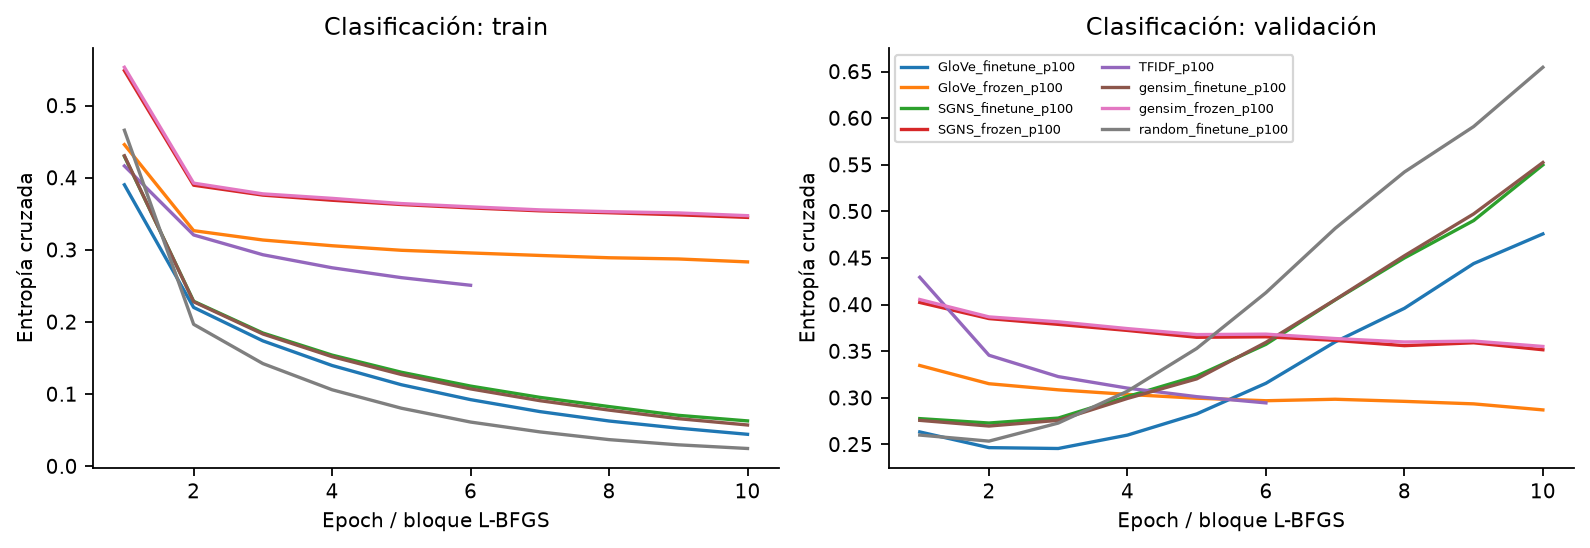

In [19]:
display(pd.Series(resultado('classification_protocol.json')))
for name, stats in resultado('classification_oov.json').items():
    print(name)
    display(pd.DataFrame(stats).T)
# Todas las variantes, seleccionadas y no seleccionadas, con métricas/tiempos/parámetros.
clf_rows = []
for path in sorted((ROOT / 'results').glob('clf_*.json')):
    r = json.loads(path.read_text())
    clf_rows.append({'name':r['name'], 'n_train':r['n_train'],
        **r['validation'], 'parameters':r['total_parameters'],
        'trainable':r['trainable_parameters'], 'seconds':r['training_seconds']})
display(pd.DataFrame(clf_rows))
figura('curvas_clasificacion.png')


TF-IDF usa unigramas, min_df=2, sublinear_tf, máximo 60,000 atributos y C=4 en regresión logística. Se registran curvas mediante seis bloques de diez iteraciones L-BFGS con warm_start. La pérdida es entropía cruzada sin el término regularizador; no son epochs de entrenamiento SGD.

,initialization,fraction,selected_run,accuracy,precision_macro,recall_macro,f1_macro
0,random,0.01,random_finetune_p1,0.773947,0.785632,0.773947,0.771237
1,SGNS,0.01,SGNS_finetune_p1,0.842763,0.843392,0.842763,0.842594
2,gensim,0.01,gensim_finetune_p1,0.848289,0.848199,0.848289,0.848114
3,GloVe,0.01,GloVe_finetune_p1,0.864474,0.864396,0.864474,0.864432
4,TFIDF,0.01,TFIDF_p1,0.839079,0.838142,0.839079,0.838050
5,random,0.10,random_finetune_p10,0.886316,0.886046,0.886316,0.886157
6,SGNS,0.10,SGNS_finetune_p10,0.889342,0.890102,0.889342,0.889454
7,gensim,0.10,gensim_finetune_p10,0.889474,0.889144,0.889474,0.889278
8,GloVe,0.10,GloVe_finetune_p10,0.898816,0.899180,0.898816,0.898887
9,TFIDF,0.10,TFIDF_p10,0.889079,0.888585,0.889079,0.888650


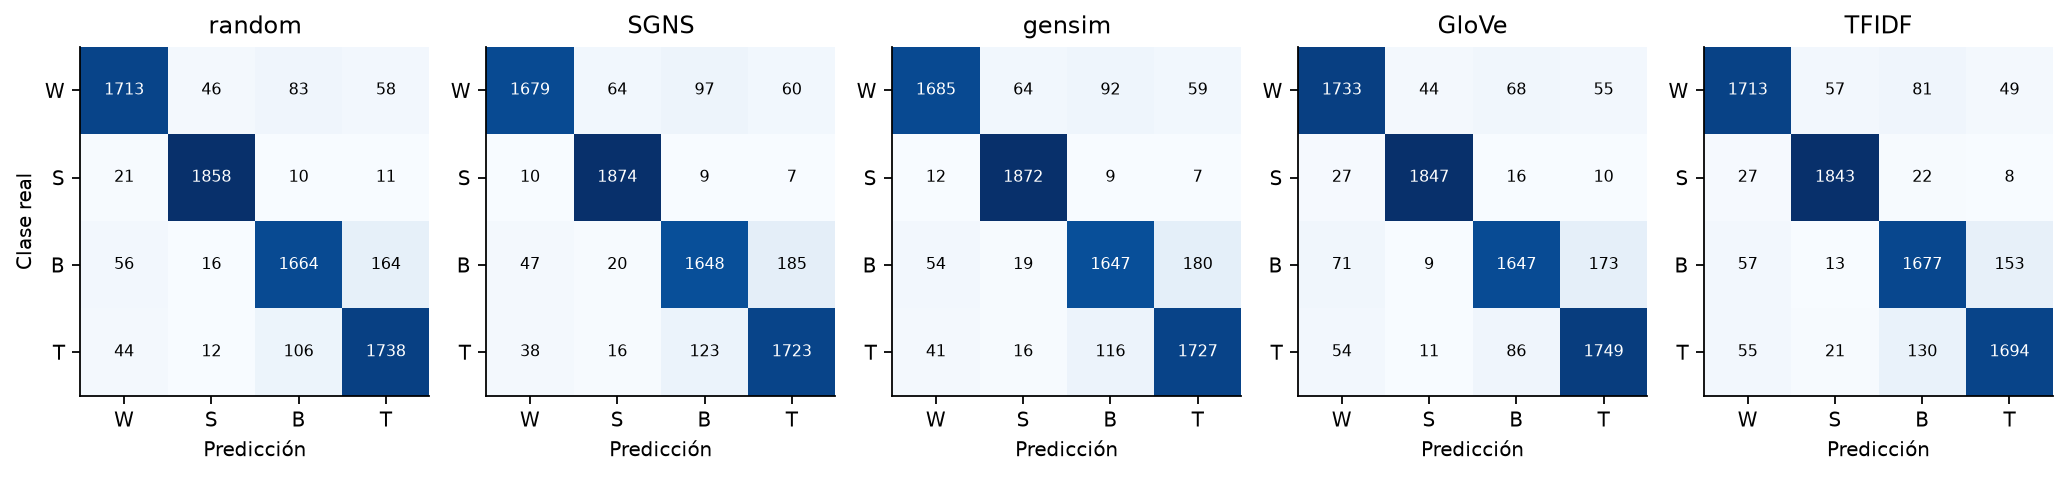

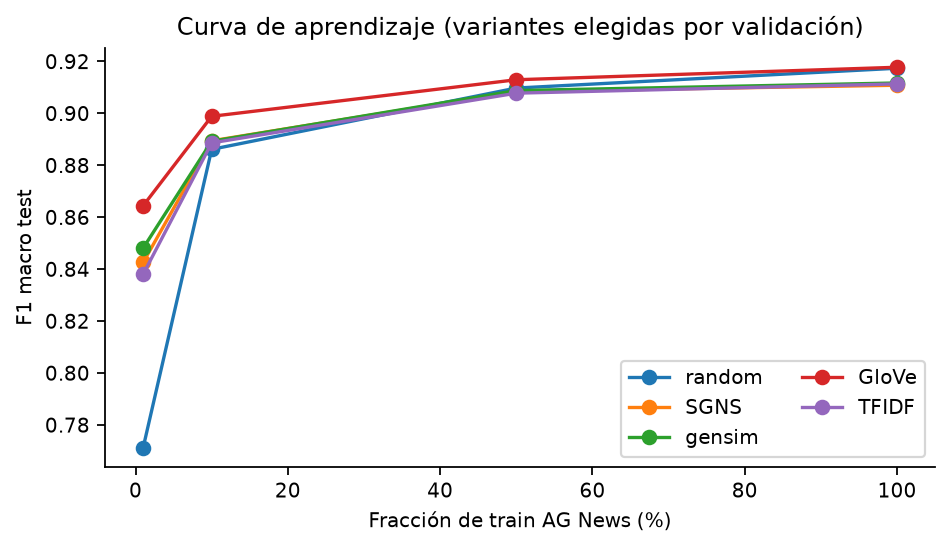

,WordSim rho,WordSim n,SimLex rho,SimLex n
SGNS,0.650361,344.0,0.269544,983.0
gensim,0.637798,344.0,0.271117,983.0
GloVe,0.532735,353.0,0.297550,999.0


In [20]:
display(pd.read_csv(ROOT / 'results/classification_test.csv'))
figura('matrices_confusion.png')
figura('f1_vs_datos.png')
# SimLex-999 reservado: evaluación final después de la selección intrínseca.
display(pd.DataFrame({name:{'WordSim rho':r['wordsim']['spearman'],
    'WordSim n':r['wordsim']['evaluated'], 'SimLex rho':r['simlex']['spearman'],
    'SimLex n':r['simlex']['evaluated']} for name,r in final.items()}).T)


## 7–8. Comparación, discusión y conclusiones


# Discusión basada en la ejecución

El modelo principal seleccionado fue **d100_w5**, epoch 3; supera el mínimo de 20 millones de tokens conocidos.

## ¿Se cumple la aritmética vectorial?

Se cumple parcialmente como recuperación de vecinos. SGNS tiene accuracy 3CosAdd 23.42%; su mejor categoría es gram6-nationality-adjective (59.89%) y su peor categoría cubierta es currency (0.93%). No implica que todos los desplazamientos sean exactos.

**SGNS:** semánticas 16.61%, sintácticas 26.53%. En man:woman :: king:queen, queen queda en rango 28, con coseno 0.639; el top-1 excluyendo es consort, y sin excluir es king. El coseno medio entre diferencias en las 21 consultas es 0.392.

**gensim:** semánticas 14.61%, sintácticas 25.94%. En man:woman :: king:queen, queen queda en rango 39, con coseno 0.607; el top-1 excluyendo es marriage, y sin excluir es king. El coseno medio entre diferencias en las 21 consultas es 0.381.

**GloVe:** semánticas 61.37%, sintácticas 67.77%. En man:woman :: king:queen, queen queda en rango 1, con coseno 0.770; el top-1 excluyendo es queen, y sin excluir es king. El coseno medio entre diferencias en las 21 consultas es 0.619.

## ¿Es una igualdad?

No. 3CosAdd usa vectores normalizados y un ranking; no exige residuo cero sobre vectores crudos. Al permitir palabras de consulta, la salida puede cambiar a una de ellas. Esto revela que parte de la cercanía procede de los términos presentes en la suma. El coseno entre diferencias mide dirección, y el residuo relativo mide discrepancia de dirección y magnitud; ninguna de las consultas acertadas constituye por sí sola una igualdad algebraica.

## Tamaño del corpus y distancia a GloVe

- 5.33M tokens, dimensión 100, w=2/k=3: 0.84% de analogías.
- 10.67M tokens, dimensión 100, w=2/k=3: 2.37% de analogías.
- 21.34M tokens, dimensión 100, w=2/k=3: 11.83% de analogías.

GloVe alcanza 65.76% con 6,000M tokens, unas 281.2 veces nuestro corpus. El aumento dentro de la ablación apoya un efecto favorable de más datos, pero los prefijos también añaden temas y cobertura. El SGNS principal puede tener otros hiperparámetros que esa ablación. No se puede repartir causalmente la brecha entre cantidad y método sin entrenar ambos métodos sobre exactamente los mismos datos y presupuesto.

## Implementación SGNS frente a gensim

La accuracy total es 23.42% en PyTorch y 22.40% en gensim; WordSim rho es 0.650 y 0.638, respectivamente. Se igualaron corpus, vocabulario y parámetros del objetivo. PyTorch suma gradientes de un minibatch; gensim actualiza por pares con cuatro workers. También difieren orden y muestras aleatorias. La coincidencia de la función de analogías y las pruebas de pérdida/gradientes verifica componentes matemáticos; no demuestra identidad de sus trayectorias de optimización.

## Dimensión, ventana y negativos

- d=50, w=2, k=3: total 11.46%; semánticas 9.36%; sintácticas 12.42%; WordSim 0.546.
- d=100, w=2, k=3: total 11.83%; semánticas 9.30%; sintácticas 12.98%; WordSim 0.551.
- d=300, w=2, k=3: total 10.89%; semánticas 8.80%; sintácticas 11.85%; WordSim 0.539.
- d=100, w=5, k=3: total 23.42%; semánticas 16.61%; sintácticas 26.53%; WordSim 0.650.
- d=100, w=2, k=5: total 15.28%; semánticas 11.62%; sintácticas 16.95%; WordSim 0.562.

Al ampliar w=2 a w=5, la mejora semántica observada es 7.31 puntos porcentuales y la sintáctica 13.55. Una ventana amplia aporta coocurrencias temáticas y más pares por epoch; el presupuesto computacional no queda constante. Una dimensión mayor no garantiza mejoras con sólo tres epochs. El número de negativos afecta objetivo, escala de pérdida y tiempo; no se ordenan modelos por pérdidas de distintos k.

## Clasificación: preentrenados, aleatorios y TF-IDF

### Con 100% de etiquetas disponibles
- TFIDF: F1 macro test 0.9114; variante elegida en validación: TFIDF_p100.
- random: F1 macro test 0.9174; variante elegida en validación: random_finetune_p100.
- SGNS: F1 macro test 0.9109; variante elegida en validación: SGNS_finetune_p100.
- gensim: F1 macro test 0.9117; variante elegida en validación: gensim_finetune_p100.
- GloVe: F1 macro test 0.9178; variante elegida en validación: GloVe_finetune_p100.
### Con 1% de etiquetas disponibles
- TFIDF: F1 macro test 0.8381; variante elegida en validación: TFIDF_p1.
- random: F1 macro test 0.7712; variante elegida en validación: random_finetune_p1.
- SGNS: F1 macro test 0.8426; variante elegida en validación: SGNS_finetune_p1.
- gensim: F1 macro test 0.8481; variante elegida en validación: gensim_finetune_p1.
- GloVe: F1 macro test 0.8644; variante elegida en validación: GloVe_finetune_p1.

Para SGNS con 100%, F1 de validación congelado=0.8777, fine-tuning=0.9057; convino fine-tuning según ese criterio. El test no se usó para tomar la decisión.

Para SGNS con 1%, F1 de validación congelado=0.8291, fine-tuning=0.8483; convino fine-tuning según ese criterio. El test no se usó para tomar la decisión.

Para GloVe con 100%, F1 de validación congelado=0.8992, fine-tuning=0.9152; convino fine-tuning según ese criterio. El test no se usó para tomar la decisión.

Para GloVe con 1%, F1 de validación congelado=0.8597, fine-tuning=0.8665; convino fine-tuning según ese criterio. El test no se usó para tomar la decisión.

Para gensim con 100%, F1 de validación congelado=0.8754, fine-tuning=0.9061; convino fine-tuning según ese criterio. El test no se usó para tomar la decisión.

Para gensim con 1%, F1 de validación congelado=0.8303, fine-tuning=0.8484; convino fine-tuning según ese criterio. El test no se usó para tomar la decisión.

Ganador observado al 100%: GloVe; al 1%: GloVe. Los embeddings preentrenados no se presumen superiores: sus resultados se comparan explícitamente con random y TF-IDF. El vocabulario fijo usa texto no etiquetado de todo train en las fracciones pequeñas; TF-IDF se ajusta sólo con su fracción. No hay intervalos de confianza y las diferencias pequeñas no prueban superioridad estadística.

## Límites

Una semilla, tres epochs de embeddings, prefijos con sesgo temático y cobertura de pares WordSim/SimLex distinta por fuente. Las analogías sí usan preguntas/candidatos idénticos. La normalización ASCII fragmenta algunos nombres y contracciones. EmbeddingBag pierde orden de palabras. t-SNE es exploratorio. Tiempo/hardware original del archivo GloVe 100d: N/D, no se atribuyen datos de otro archivo. Todas las cifras proceden de los JSON ejecutados; no se usan métricas simuladas.


In [21]:
clf = resultado('classification_final.json')
full = {r['initialization']:r for r in clf if r['fraction']==1}
small = {r['initialization']:r for r in clf if r['fraction']==.01}
oov = resultado('classification_oov.json')
comparison = []
for name, r in final.items():
    comparison.append({'modelo':name, 'tokens':6_000_000_000 if name=='GloVe' else sgns_run['corpus_tokens_known'],
        'vocabulario':r['vocab_size'], 'dim':r['dim'],
        'tiempo_s':None if name=='GloVe' else (ref if name=='gensim' else sgns_run)['training_seconds'],
        'hardware':'Original 100d: N/D' if name=='GloVe' else 'Apple M1 Pro, CPU',
        'Add_sem':r['analogies']['add']['accuracy']['semantic'],
        'Add_sint':r['analogies']['add']['accuracy']['syntactic'],
        'Add_total':r['analogies']['add']['accuracy']['total'],
        'Mul_sem':r['analogies']['mul']['accuracy']['semantic'],
        'Mul_sint':r['analogies']['mul']['accuracy']['syntactic'],
        'Mul_total':r['analogies']['mul']['accuracy']['total'],
        'WordSim':r['wordsim']['spearman'], 'SimLex':r['simlex']['spearman'],
        'paralelismo':r['individual']['parallelism_mean'],
        'AGNews_OOV_test_pct':oov[name]['test']['source_oov_percent'],
        'F1_test':full[name]['test']['f1_macro']})
display(pd.DataFrame(comparison))


,modelo,tokens,vocabulario,dim,tiempo_s,hardware,Add_sem,Add_sint,Add_total,Mul_sem,Mul_sint,Mul_total,WordSim,SimLex,paralelismo,AGNews_OOV_test_pct,F1_test
0,SGNS,21336925,38569,100,458.814827,"Apple M1 Pro, CPU",0.166097,0.265301,0.234244,0.152694,0.223979,0.201662,0.650361,0.269544,0.392487,5.382137,0.910852
1,gensim,21336925,38569,100,39.976705,"Apple M1 Pro, CPU",0.146124,0.259432,0.223959,0.136137,0.211882,0.188169,0.637798,0.271117,0.380802,5.382137,0.911731
2,GloVe,6000000000,400000,100,NaN,Original 100d: N/D,0.613666,0.677686,0.657644,0.587911,0.662475,0.639131,0.532735,0.297550,0.619119,0.509360,0.917785


In [22]:
# Respuestas basadas en resultados, sin asumir de antemano al ganador.
categories = final['SGNS']['analogies']['add']['categories']
covered = [r for r in categories if r['accuracy'] is not None]
strong = max(covered, key=lambda r:r['accuracy'])
weak = min(covered, key=lambda r:r['accuracy'])
print('Mejor/peor categoría SGNS:', strong['category'], strong['accuracy'], '/', weak['category'], weak['accuracy'])
print('Semántica y sintaxis:', final['SGNS']['analogies']['add']['accuracy'])
for name,r in final.items():
    q=r['individual']['queries'][0]
    print(name, 'king-man+woman:', q['top5'], '| sin exclusión:', q['without_exclusion'])
print('F1 al 100%:', {n:r['test']['f1_macro'] for n,r in full.items()})
print('F1 al 1%:', {n:r['test']['f1_macro'] for n,r in small.items()})
print('Variantes elegidas 100%:', {n:r['selected_run'] for n,r in full.items()})
print('Variantes elegidas 1%:', {n:r['selected_run'] for n,r in small.items()})


Mejor/peor categoría SGNS: gram6-nationality-adjective 0.5989222478829869 / currency 0.009259259259259259
Semántica y sintaxis: {'semantic': 0.16609724047306176, 'syntactic': 0.2653012336806803, 'total': 0.2342438703307553}
SGNS king-man+woman: [['consort', 0.7051764726638794], ['marriage', 0.6880382299423218], ['childless', 0.6849664449691772], ['sibyl', 0.6821231842041016], ['violante', 0.6667181849479675]] | sin exclusión: [['king', 0.7234075665473938], ['consort', 0.7051764726638794], ['marriage', 0.6880382299423218], ['childless', 0.6849664449691772], ['sibyl', 0.6821231842041016]]
gensim king-man+woman: [['marriage', 0.6817952394485474], ['consort', 0.6589519381523132], ['regent', 0.6448789834976196], ['childless', 0.6441709995269775], ['duchess', 0.6410714387893677]] | sin exclusión: [['king', 0.7126541137695312], ['marriage', 0.6817952394485474], ['consort', 0.6589519381523132], ['regent', 0.6448789834976196], ['childless', 0.6441709995269775]]
GloVe king-man+woman: [['queen', 

**Aritmética.** Los resultados por categoría, rangos y cosenos muestran relaciones aproximadas, no igualdades. Sin exclusión, términos de consulta pueden quedar primeros. El coseno de diferencias y el residuo relativo permiten comprobar que paralelismo y coincidencia algebraica son cosas distintas.

**Escala de datos.** La curva con 25/50/100% mantiene d=100, w=2 y k=3. Permite observar la tendencia de cantidad/composición del corpus, pero no separar causalmente el método del dominio: GloVe usa aproximadamente 6,000M tokens frente a 21M de WikiText. No se atribuye toda la brecha a una sola causa.

**Implementación.** La tendencia SGNS/gensim debe compararse con sus métricas, no con sus pérdidas de distinta escala. Gensim aplica actualizaciones online en varios workers; PyTorch suma un minibatch, baraja pares y genera otras muestras. Igualar hiperparámetros no hace idénticas esas trayectorias.

**Dimensión, ventana y negativos.** La tabla de iteraciones responde con resultados observados: subir dimensión no necesariamente ayuda con pocas epochs. Las ventanas cortas suelen capturar contexto sintáctico y las amplias contexto temático, pero las categorías medidas son la evidencia de este experimento. Más negativos modifica objetivo y costo; una pérdida mayor puede acompañar mejores representaciones.

**Clasificación.** La comparación incluye todas las variantes en validación, y en test sólo ganadores. Los resultados impresos muestran si superan random o TF-IDF, y qué variante convino al 100% y al 1%. Congelar reduce parámetros entrenables; fine-tuning permite adaptar al dominio. Esto no garantiza de antemano cuál obtiene mejor F1.

**Límites.** Una semilla, tres epochs, prefijos con sesgo temático, cobertura intrínseca diferente en WordSim/SimLex y posibles dimensiones distintas entre fuentes. No se presentan intervalos de confianza ni se generaliza una tendencia como ley causal. t-SNE es exploratorio. Tiempo/hardware exactos del GloVe 100d: no disponibles en fuentes consultadas.

## Validación de la implementación y entregables
Se verifican pares sin cruzar líneas, la fórmula de subsampling, la pérdida inicial y sus gradientes, equivalencia 3CosAdd con gensim y agregación por offsets. Los resultados completos están en JSON/CSV; los vectores finales en `models/mejor_sgns.txt`, formato word2vec de texto. El informe resume la ejecución en cinco páginas.

Referencias principales: [PyTorch](https://docs.pytorch.org/docs/2.14/generated/torch.nn.Embedding.html), [EmbeddingBag](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.sparse.EmbeddingBag.html), [gensim Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html), [KeyedVectors](https://radimrehurek.com/gensim/models/keyedvectors.html), [Mikolov et al.](https://arxiv.org/abs/1310.4546), [GloVe](https://nlp.stanford.edu/projects/glove/), [Pennington et al.](https://aclanthology.org/D14-1162/).

In [23]:
subprocess.run([sys.executable, 'scripts/verify_pipeline.py'], check=True)
print('Informe:', ROOT / 'output/pdf/Laboratorio_7_Informe.pdf')
print('Vectores:', ROOT / 'models/mejor_sgns.txt')


PASS: tokenización, pares sin cruzar líneas, subsampling, pérdida SGNS, gradientes, 3CosAdd/3CosMul y EmbeddingBag/offsets.


Informe: /Users/javiervalladares/Library/Mobile Documents/com~apple~CloudDocs/Octavo Semestre/IA/Embeddings/output/pdf/Laboratorio_7_Informe.pdf
Vectores: /Users/javiervalladares/Library/Mobile Documents/com~apple~CloudDocs/Octavo Semestre/IA/Embeddings/models/mejor_sgns.txt


### Integridad de la ejecución
Se verificaron 21 epochs SGNS, 30,000 candidatos comunes, 12,154 preguntas compartidas y matrices de confusión con 7,600 casos. Los vectores de SGNS y gensim son finitos y no nulos. La rueda oficial gensim 4.4.0 emitió mensajes Cython `our_dot_float`; no se modificó Word2Vec ni se ocultaron los avisos. La pérdida finita y las métricas por epoch, además de la auditoría `results/audit.json`, permiten revisar la referencia con esta limitación del entorno. Las versiones exactas quedan en `requirements-lock.txt`.

## Repositorio de entrega

[https://github.com/Javiervalladares1/Laboratorio-7-NLP-Embeddings](https://github.com/Javiervalladares1/Laboratorio-7-NLP-Embeddings)

Repositorio privado. Dar acceso al profesor y al compañero para la revisión. Vectores: `models/mejor_sgns.txt.gz`; el notebook los descomprime si hace falta.